# Questão 1(b) - CNN com Transfer Learning

Classificação binária `Cat` vs `Dog` usando modelos pré-treinados no ImageNet:

- VGG16;
- ResNet50;
- MobileNetV2.

O notebook usa o mesmo protocolo da questão: holdout com 70% treino e 30% teste. A validação é retirada apenas do conjunto de treino para early stopping, sem tocar no teste.

## 0. Dependências

TensorFlow não tinha wheel estável para Python 3.14 neste ambiente. Use kernel Python 3.13 ou 3.12 para executar este notebook.

In [19]:
import importlib.util
import subprocess
import sys

if sys.version_info >= (3, 14) and importlib.util.find_spec("tensorflow") is None:
    raise RuntimeError(
        "TensorFlow não está instalado e este kernel usa Python 3.14. "
        "Crie/use um kernel Python 3.13 ou 3.12. Exemplo: "
        "uv venv .venv-tf --python 3.13 && "
        "uv pip install --python .venv-tf/bin/python tensorflow opencv-python scikit-learn pandas matplotlib tqdm ipykernel"
    )

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tensorflow": "tensorflow",
    "tqdm": "tqdm",
}

missing = [package for module, package in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Instalando dependências ausentes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Dependências já instaladas.")

Dependências já instaladas.


## 1. Imports

In [20]:
from pathlib import Path
import gc
import math
import random
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

warnings.filterwarnings("ignore")
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("TensorFlow:", tf.__version__)
print("GPUs:", gpus if gpus else "nenhuma; usando CPU")

TensorFlow: 2.21.0
GPUs: nenhuma; usando CPU


## 2. Configuração

In [21]:
DATA_DIR = Path("PetImages")
OUTPUT_DIR = Path("outputs/partB")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_TO_LABEL = {"Cat": 0, "Dog": 1}
LABEL_TO_CLASS = {label: name for name, label in CLASS_TO_LABEL.items()}
CLASS_NAMES = ["Cat", "Dog"]

RANDOM_STATE = 42
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.15  # fração retirada dos 70% de treino
IMG_SIZE = (224, 224)  # (largura, altura)
BATCH_SIZE = 32
EPOCHS = 8
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Use None para dataset inteiro. Se treino ficar lento, teste 2000 ou 4000 por classe.
MAX_IMAGES_PER_CLASS = None

# Fine-tuning opcional. 0 = somente classificador sobre base congelada.
FINE_TUNE_EPOCHS = 0
FINE_TUNE_LAST_N_LAYERS = 30
FINE_TUNE_LEARNING_RATE = 1e-5

print(f"Dataset: {DATA_DIR.resolve()}")
print(f"Saídas: {OUTPUT_DIR.resolve()}")

Dataset: /home/gui/Documents/code/vc/Lista 04/PetImages
Saídas: /home/gui/Documents/code/vc/Lista 04/outputs/partB


## 3. Validação das imagens

In [22]:
def tensorflow_can_decode(path):
    try:
        image_bytes = tf.io.read_file(str(path))
        image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        _ = image.numpy().shape  # força decode agora, fora do treino
        return True, "ok"
    except Exception as exc:
        return False, str(exc).split("\n")[0]

def collect_valid_images(data_dir, class_to_label, max_images_per_class=None):
    rows = []
    bad_rows = []
    rng = np.random.default_rng(RANDOM_STATE)

    for class_name, label in class_to_label.items():
        class_dir = data_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Pasta não encontrada: {class_dir}")

        candidates = sorted(
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
        )

        valid_paths = []
        for path in tqdm(candidates, desc=f"Validando {class_name}"):
            image = cv2.imread(str(path))
            if image is None:
                bad_rows.append({"path": str(path), "reason": "OpenCV não leu a imagem"})
                continue

            tf_ok, tf_reason = tensorflow_can_decode(path)
            if not tf_ok:
                bad_rows.append({"path": str(path), "reason": f"TensorFlow decode falhou: {tf_reason}"})
                continue
            valid_paths.append(path)

        if max_images_per_class is not None and len(valid_paths) > max_images_per_class:
            valid_paths = list(rng.choice(valid_paths, size=max_images_per_class, replace=False))

        rows.extend(
            {"path": str(path), "label": label, "class_name": class_name}
            for path in valid_paths
        )

    return pd.DataFrame(rows), pd.DataFrame(bad_rows)

df, bad_df = collect_valid_images(DATA_DIR, CLASS_TO_LABEL, MAX_IMAGES_PER_CLASS)

if len(bad_df):
    bad_df.to_csv(OUTPUT_DIR / "bad_images.csv", index=False)

print(f"Imagens válidas: {len(df)}")
print(f"Imagens corrompidas/ilegíveis/incompatíveis com TensorFlow: {len(bad_df)}")
display(df["class_name"].value_counts().reindex(CLASS_NAMES).to_frame("quantidade"))
if len(bad_df):
    display(bad_df.head())
df.head()

Validando Cat:  20%|█▉        | 2438/12499 [00:01<00:07, 1285.24it/s]Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Validando Cat:  23%|██▎       | 2843/12499 [00:02<00:07, 1290.43it/s]Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Validando Cat:  25%|██▍       | 3110/12499 [00:02<00:07, 1297.98it/s]Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Validando Cat:  68%|██████▊   | 8466/12499 [00:06<00:03, 1264.88it/s]Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Validando Cat:  74%|███████▍  | 9283/12499 [00:06<00:02, 1363.93it/s]Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Validando Dog:  18%|█▊        | 2282/12499 [00:01<00:08, 1237.24i

Imagens válidas: 24991
Imagens corrompidas/ilegíveis/incompatíveis com TensorFlow: 7


,quantidade
class_name,
Cat,12497
Dog,12494


,path,reason
0,PetImages/Cat/10404.jpg,OpenCV não leu a imagem
1,PetImages/Cat/4351.jpg,TensorFlow decode falhou: {{function_node __wr...
2,PetImages/Dog/11233.jpg,TensorFlow decode falhou: {{function_node __wr...
3,PetImages/Dog/11912.jpg,TensorFlow decode falhou: {{function_node __wr...
4,PetImages/Dog/2317.jpg,TensorFlow decode falhou: {{function_node __wr...


,path,label,class_name
0,PetImages/Cat/0.jpg,0,Cat
1,PetImages/Cat/1.jpg,0,Cat
2,PetImages/Cat/10.jpg,0,Cat
3,PetImages/Cat/100.jpg,0,Cat
4,PetImages/Cat/1000.jpg,0,Cat


## 4. Split holdout 70/30

In [23]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

train_model_df, val_df = train_test_split(
    train_df,
    test_size=VALIDATION_SIZE,
    stratify=train_df["label"],
    random_state=RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True)
train_model_df = train_model_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "treino_total_70pct": train_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "treino_modelo": train_model_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "validacao": val_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "teste_30pct": test_df["class_name"].value_counts().reindex(CLASS_NAMES),
})

print(f"Treino total: {len(train_df)} imagens ({len(train_df) / len(df):.1%})")
print(f"Teste: {len(test_df)} imagens ({len(test_df) / len(df):.1%})")
display(split_summary)

Treino total: 17493 imagens (70.0%)
Teste: 7498 imagens (30.0%)


,treino_total_70pct,treino_modelo,validacao,teste_30pct
class_name,,,,
Cat,8748,7436,1312,3749
Dog,8745,7433,1312,3749


## 5. Dataset TensorFlow

As imagens são carregadas em RGB, convertidas para `float32` e redimensionadas para `224x224` com padding para preservar a proporção. Cada modelo aplica seu próprio `preprocess_input`.

In [24]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_HEIGHT, IMG_WIDTH = IMG_SIZE[1], IMG_SIZE[0]

def load_image_tf(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMG_HEIGHT, IMG_WIDTH)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(frame, shuffle=False):
    paths = frame["path"].to_numpy(dtype=str)
    labels = frame["label"].to_numpy(dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(frame), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return (
        dataset
        .map(load_image_tf, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

train_ds = make_dataset(train_model_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## 6. Exemplos do dataset

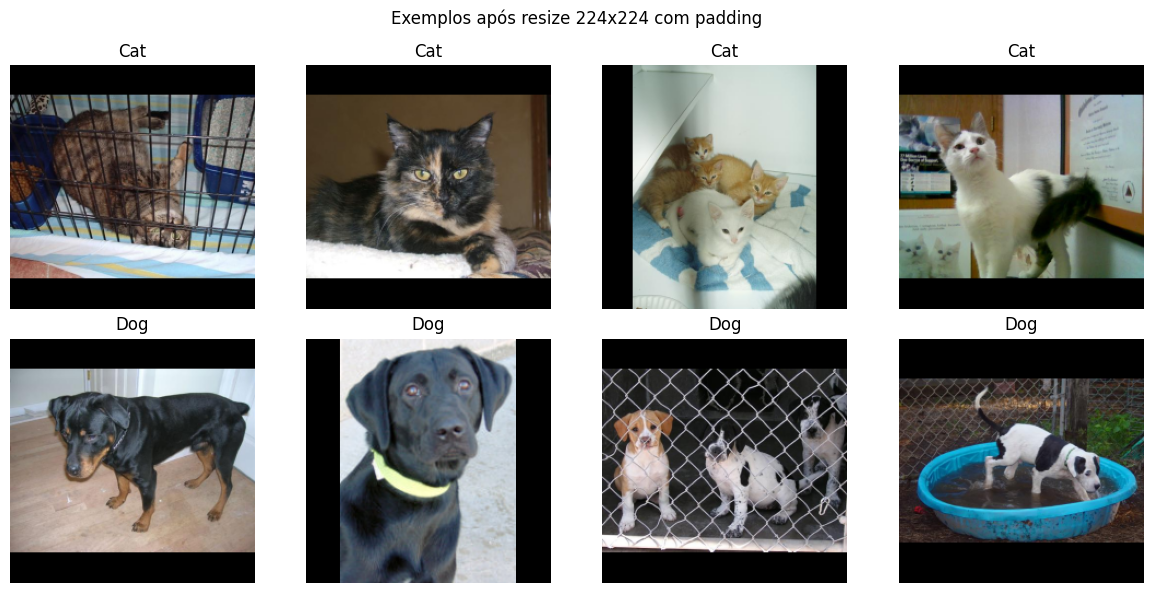

In [25]:
def resize_to_square_cv2(image, img_size=IMG_SIZE, pad_color=0):
    target_w, target_h = img_size
    h, w = image.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(image, (new_w, new_h), interpolation=interpolation)
    canvas = np.full((target_h, target_w, image.shape[2]), pad_color, dtype=image.dtype)
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def load_rgb_resized(path, img_size=IMG_SIZE):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Imagem ilegível: {path}")
    image = resize_to_square_cv2(image, img_size=img_size)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample_parts = []
for class_name in CLASS_NAMES:
    group = train_model_df[train_model_df["class_name"] == class_name]
    if len(group):
        sample_parts.append(group.sample(min(4, len(group)), random_state=RANDOM_STATE))

sample_df = pd.concat(sample_parts).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    ax.imshow(load_rgb_resized(row["path"]))
    ax.set_title(row["class_name"])
    ax.axis("off")

for ax in axes.ravel()[len(sample_df):]:
    ax.axis("off")

fig.suptitle("Exemplos após resize 224x224 com padding")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Modelos e funções de treino

In [26]:
MODEL_SPECS = {
    "VGG16": {
        "base_fn": tf.keras.applications.VGG16,
        "preprocess": tf.keras.applications.vgg16.preprocess_input,
    },
    "ResNet50": {
        "base_fn": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
    },
    "MobileNetV2": {
        "base_fn": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
    },
}

MODEL_ORDER = ["VGG16", "ResNet50", "MobileNetV2"]

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=RANDOM_STATE),
        tf.keras.layers.RandomRotation(0.05, seed=RANDOM_STATE),
        tf.keras.layers.RandomZoom(0.10, seed=RANDOM_STATE),
    ],
    name="data_augmentation",
)

def build_transfer_model(model_name):
    spec = MODEL_SPECS[model_name]
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="image")
    x = data_augmentation(inputs)
    x = spec["preprocess"](x)

    base_model = spec["base_fn"](
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="cat_dog_probability")(x)

    model = tf.keras.Model(inputs, outputs, name=f"{model_name}_transfer")
    compile_model(model, LEARNING_RATE)
    return model, base_model

def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

def history_to_frame(history, phase):
    frame = pd.DataFrame(history.history)
    frame["epoch"] = np.arange(1, len(frame) + 1)
    frame["phase"] = phase
    return frame

In [27]:
def plot_history(history_df, model_name, model_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["loss"], label="treino")
    if "val_loss" in history_df:
        axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validação")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["accuracy"], label="treino")
    if "val_accuracy" in history_df:
        axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validação")
    axes[1].set_title("Acurácia")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    fig.suptitle(f"Curvas de treino - {model_name}")
    fig.tight_layout()
    fig.savefig(model_dir / f"training_curves_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def predict_dataset(model, dataset):
    probabilities = model.predict(dataset, verbose=1).reshape(-1)
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions

def save_confusion_matrix(y_true, y_pred, model_name, model_dir, accuracy, macro_f1):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        model_dir / f"confusion_matrix_{model_name}.csv"
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    ax.set_title(f"{model_name}\nAcc: {accuracy:.4f} | F1 macro: {macro_f1:.4f}")
    fig.tight_layout()
    fig.savefig(model_dir / f"confusion_matrix_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def save_prediction_examples(pred_df, model_name, model_dir):
    pieces = []
    for class_name in CLASS_NAMES:
        subset = pred_df[(pred_df["class_name"] == class_name) & pred_df["correct"]]
        if len(subset):
            pieces.append(subset.sample(min(2, len(subset)), random_state=RANDOM_STATE))

    wrong_subset = pred_df[~pred_df["correct"]]
    if len(wrong_subset):
        pieces.append(wrong_subset.sample(min(4, len(wrong_subset)), random_state=RANDOM_STATE))

    if not pieces:
        print(f"Sem exemplos para plotar em {model_name}.")
        return pd.DataFrame()

    example_df = pd.concat(pieces).reset_index(drop=True)
    example_df.to_csv(model_dir / f"prediction_examples_{model_name}.csv", index=False)

    cols = 4
    rows = max(1, math.ceil(len(example_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, example_df.iterrows()):
        ax.imshow(load_rgb_resized(row["path"]))
        color = "green" if row["correct"] else "red"
        status = "acerto" if row["correct"] else "erro"
        ax.set_title(
            f"Real: {row['class_name']}\nPred: {row['pred_class']} ({status})\np(Dog)={row['prob_dog']:.2f}",
            color=color,
        )
        ax.axis("off")

    for ax in axes[len(example_df):]:
        ax.axis("off")

    fig.suptitle(f"Exemplos de predição - {model_name}")
    fig.tight_layout()
    fig.savefig(model_dir / f"prediction_examples_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return example_df

## 8. Treino e avaliação dos 3 modelos

A primeira execução baixa os pesos ImageNet automaticamente. Se a internet estiver indisponível, baixe os pesos antes ou execute em ambiente com acesso.

In [28]:
def train_and_evaluate_model(model_name):
    tf.keras.backend.clear_session()
    gc.collect()

    model_dir = OUTPUT_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Treinando {model_name}")
    print("=" * 80)

    model, base_model = build_transfer_model(model_name)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(model_dir / f"best_{model_name}.keras"),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    history_frames = []
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    history_frames.append(history_to_frame(history, "frozen_base"))

    if FINE_TUNE_EPOCHS > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-FINE_TUNE_LAST_N_LAYERS]:
            layer.trainable = False

        compile_model(model, FINE_TUNE_LEARNING_RATE)
        fine_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FINE_TUNE_EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )
        history_frames.append(history_to_frame(fine_history, "fine_tuning"))

    history_df = pd.concat(history_frames, ignore_index=True)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df.to_csv(model_dir / f"history_{model_name}.csv", index=False)
    plot_history(history_df, model_name, model_dir)

    model.save(model_dir / f"final_{model_name}.keras")

    y_test = test_df["label"].to_numpy(dtype=int)
    probabilities, predictions = predict_dataset(model, test_ds)

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(y_test, predictions, average="macro")
    weighted_f1 = f1_score(y_test, predictions, average="weighted")
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)

    report = classification_report(
        y_test,
        predictions,
        target_names=CLASS_NAMES,
        digits=4,
    )
    print(report)
    (model_dir / f"classification_report_{model_name}.txt").write_text(report, encoding="utf-8")

    save_confusion_matrix(y_test, predictions, model_name, model_dir, accuracy, macro_f1)

    pred_df = test_df.copy()
    pred_df["prob_dog"] = probabilities
    pred_df["pred_label"] = predictions
    pred_df["pred_class"] = pred_df["pred_label"].map(LABEL_TO_CLASS)
    pred_df["correct"] = pred_df["label"] == pred_df["pred_label"]
    pred_df.to_csv(model_dir / f"test_predictions_{model_name}.csv", index=False)
    example_df = save_prediction_examples(pred_df, model_name, model_dir)

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision_dog": precision,
        "recall_dog": recall,
        "train_total_size": len(train_df),
        "train_model_size": len(train_model_df),
        "validation_size": len(val_df),
        "test_size": len(test_df),
        "epochs_configured": EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "examples_saved": len(example_df),
    }

Treinando VGG16
Epoch 1/8
 31/465 ━━━━━━━━━━━━━━━━━━━━ 7:55 1s/step - accuracy: 0.5383 - loss: 2.4341 - precision: 0.5666 - recall: 0.4795

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


153/465 ━━━━━━━━━━━━━━━━━━━━ 5:52 1s/step - accuracy: 0.5668 - loss: 2.1337 - precision: 0.5753 - recall: 0.5462

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


292/465 ━━━━━━━━━━━━━━━━━━━━ 3:15 1s/step - accuracy: 0.5924 - loss: 1.9545 - precision: 0.5982 - recall: 0.5872

...

358/465 ━━━━━━━━━━━━━━━━━━━━ 2:01 1s/step - accuracy: 0.9417 - loss: 0.1745 - precision: 0.9466 - recall: 0.9373

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9427 - loss: 0.1710 - precision: 0.9467 - recall: 0.9391

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.9461 - loss: 0.1593 - precision: 0.9471 - recall: 0.9448 - val_accuracy: 0.9748 - val_loss: 0.0780 - val_precision: 0.9734 - val_recall: 0.9764


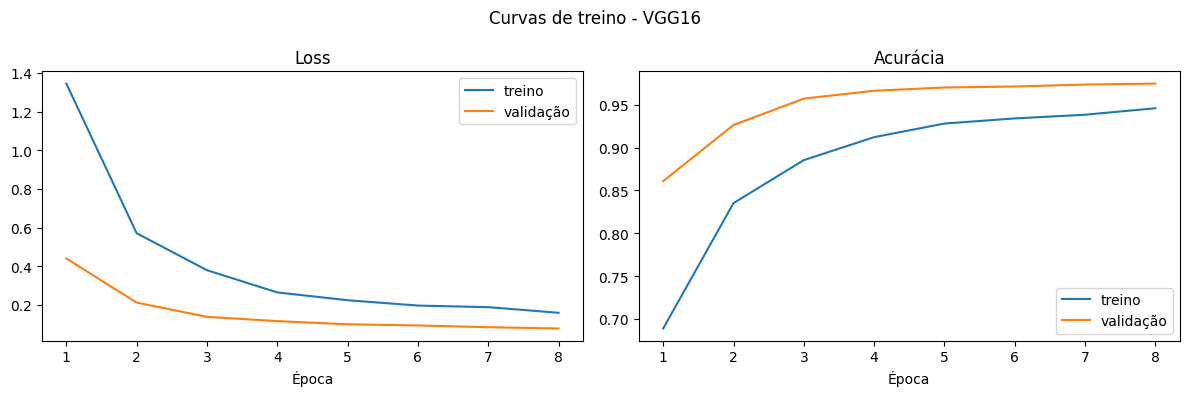

 56/235 ━━━━━━━━━━━━━━━━━━━━ 3:21 1s/step

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


106/235 ━━━━━━━━━━━━━━━━━━━━ 2:24 1s/step

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


153/235 ━━━━━━━━━━━━━━━━━━━━ 1:31 1s/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step
              precision    recall  f1-score   support

         Cat     0.9796    0.9733    0.9765      3749
         Dog     0.9735    0.9797    0.9766      3749

    accuracy                         0.9765      7498
   macro avg     0.9765    0.9765    0.9765      7498
weighted avg     0.9765    0.9765    0.9765      7498



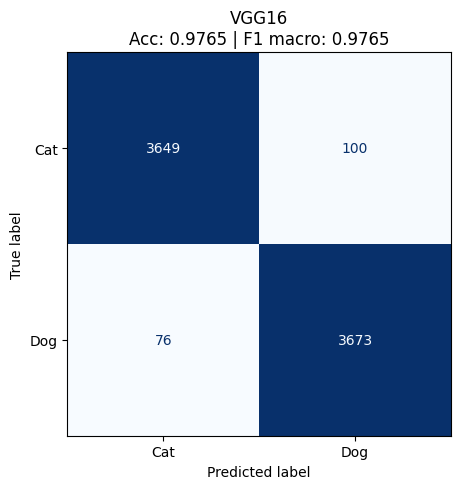

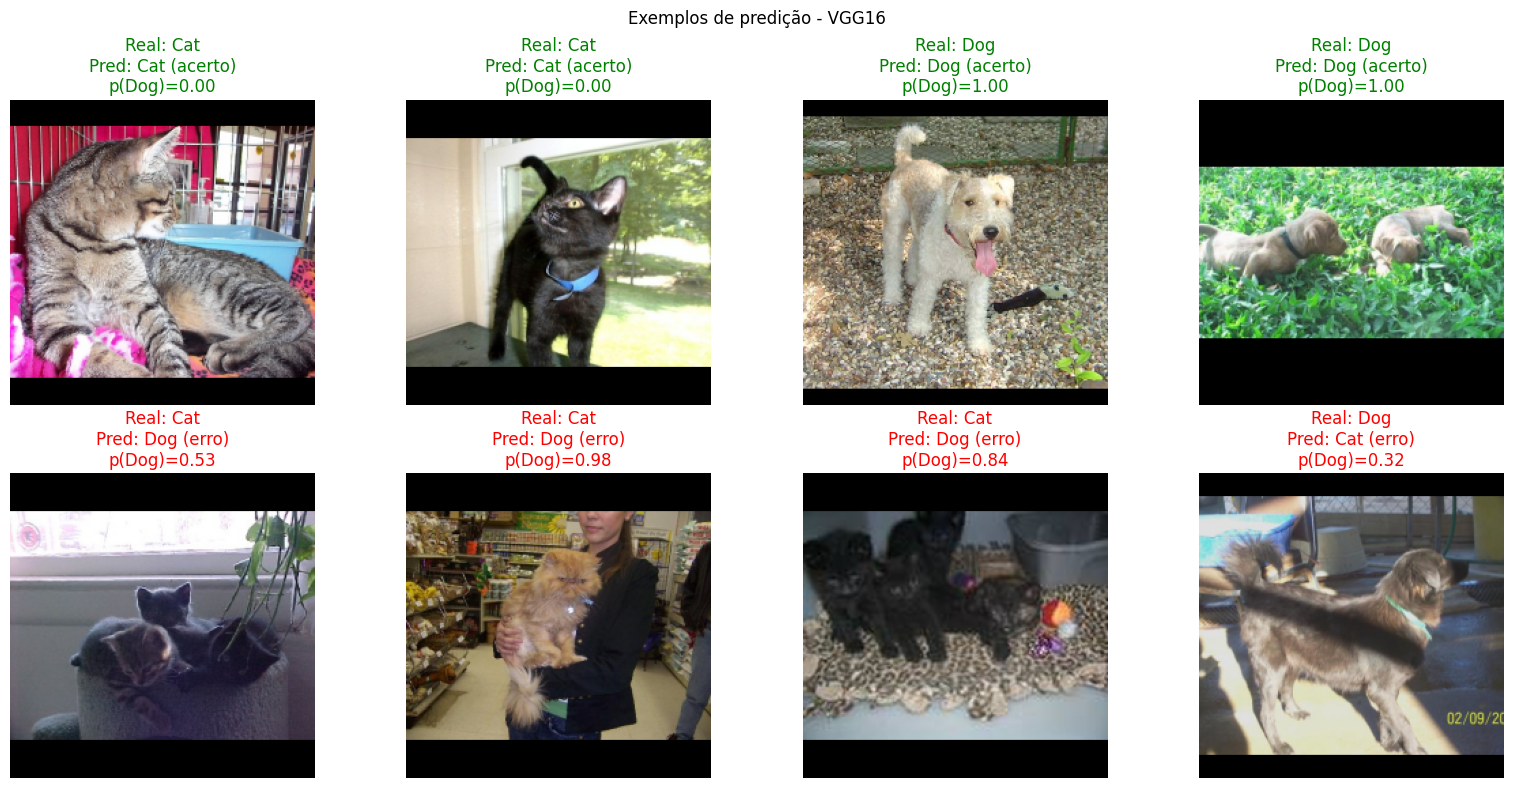

Treinando ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/8
 94/465 ━━━━━━━━━━━━━━━━━━━━ 3:38 590ms/step - accuracy: 0.6898 - loss: 0.5905 - precision: 0.7399 - recall: 0.6234

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


229/465 ━━━━━━━━━━━━━━━━━━━━ 2:20 594ms/step - accuracy: 0.7706 - loss: 0.4832 - precision: 0.8012 - recall: 0.7298

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


250/465 ━━━━━━━━━━━━━━━━━━━━ 2:07 594ms/step - accuracy: 0.7788 - loss: 0.4713 - precision: 0.8078 - recall: 0.7402

...

275/465 ━━━━━━━━━━━━━━━━━━━━ 1:54 601ms/step - accuracy: 0.9829 - loss: 0.0494 - precision: 0.9819 - recall: 0.9840

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9828 - loss: 0.0494 - precision: 0.9822 - recall: 0.9833

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 327s 703ms/step - accuracy: 0.9826 - loss: 0.0486 - precision: 0.9832 - recall: 0.9821 - val_accuracy: 0.9870 - val_loss: 0.0310 - val_precision: 0.9797 - val_recall: 0.9947


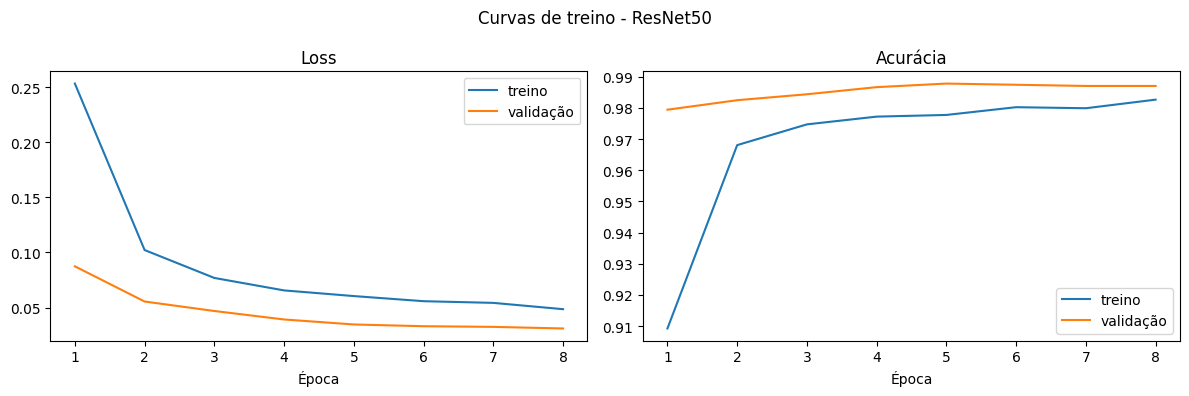

 57/235 ━━━━━━━━━━━━━━━━━━━━ 1:44 585ms/step

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


107/235 ━━━━━━━━━━━━━━━━━━━━ 1:14 585ms/step

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


154/235 ━━━━━━━━━━━━━━━━━━━━ 47s 585ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 138s 586ms/step
              precision    recall  f1-score   support

         Cat     0.9922    0.9856    0.9889      3749
         Dog     0.9857    0.9923    0.9890      3749

    accuracy                         0.9889      7498
   macro avg     0.9890    0.9889    0.9889      7498
weighted avg     0.9890    0.9889    0.9889      7498



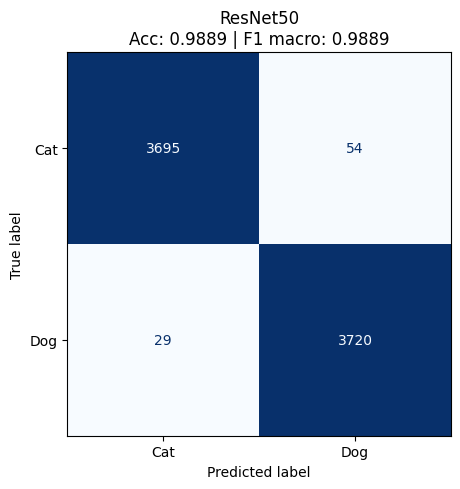

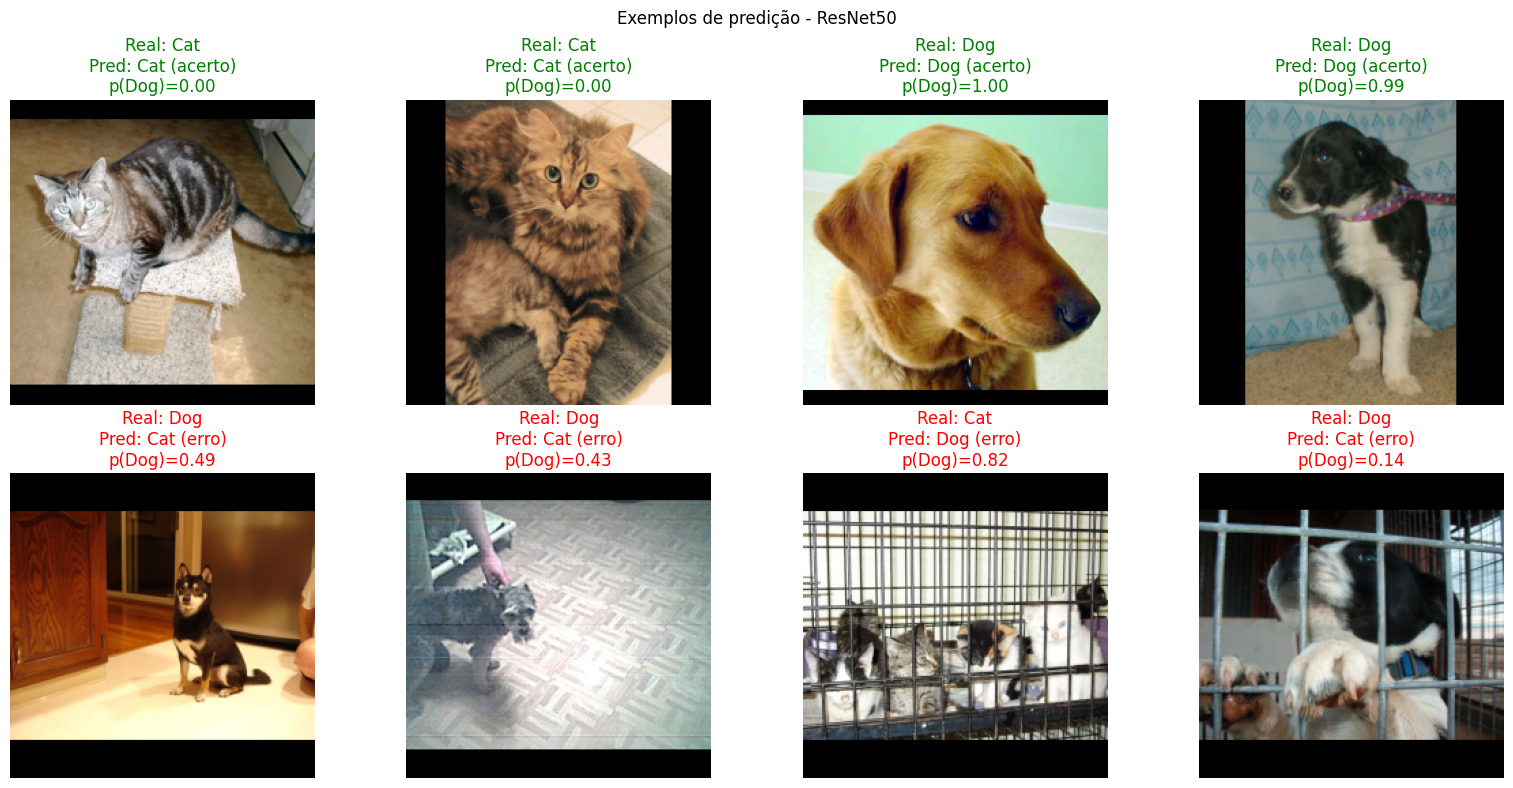

Treinando MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
  2/465 ━━━━━━━━━━━━━━━━━━━━ 1:36 209ms/step - accuracy: 0.4688 - loss: 1.0318 - precision: 0.4760 - recall: 0.9531

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


105/465 ━━━━━━━━━━━━━━━━━━━━ 1:13 204ms/step - accuracy: 0.5554 - loss: 0.7859 - precision: 0.5453 - recall: 0.7246

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


177/465 ━━━━━━━━━━━━━━━━━━━━ 58s 204ms/step - accuracy: 0.6095 - loss: 0.7123 - precision: 0.5960 - recall: 0.7279

...

324/465 ━━━━━━━━━━━━━━━━━━━━ 28s 204ms/step - accuracy: 0.9754 - loss: 0.0677 - precision: 0.9741 - recall: 0.9764

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9751 - loss: 0.0683 - precision: 0.9734 - recall: 0.9766

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


465/465 ━━━━━━━━━━━━━━━━━━━━ 111s 238ms/step - accuracy: 0.9746 - loss: 0.0700 - precision: 0.9719 - recall: 0.9775 - val_accuracy: 0.9806 - val_loss: 0.0506 - val_precision: 0.9737 - val_recall: 0.9878


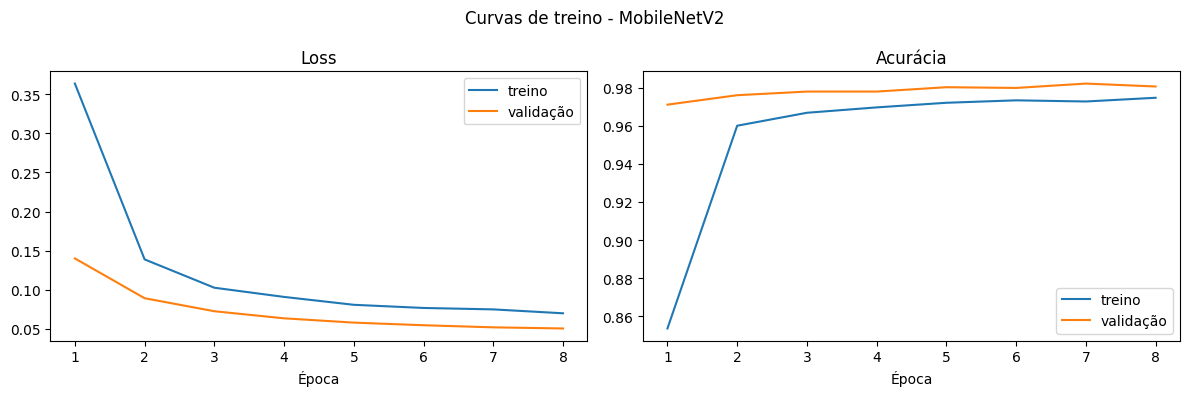

 58/235 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


108/235 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


155/235 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 193ms/step
              precision    recall  f1-score   support

         Cat     0.9884    0.9808    0.9846      3749
         Dog     0.9809    0.9885    0.9847      3749

    accuracy                         0.9847      7498
   macro avg     0.9847    0.9847    0.9847      7498
weighted avg     0.9847    0.9847    0.9847      7498



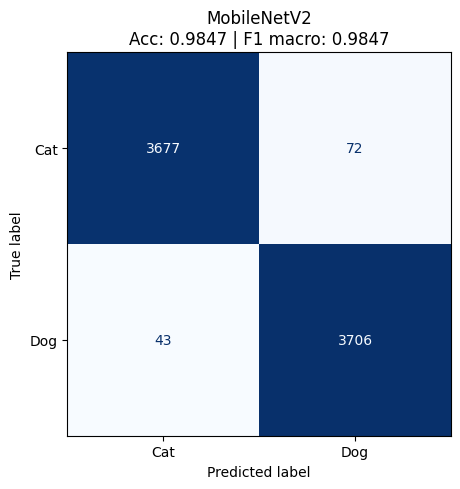

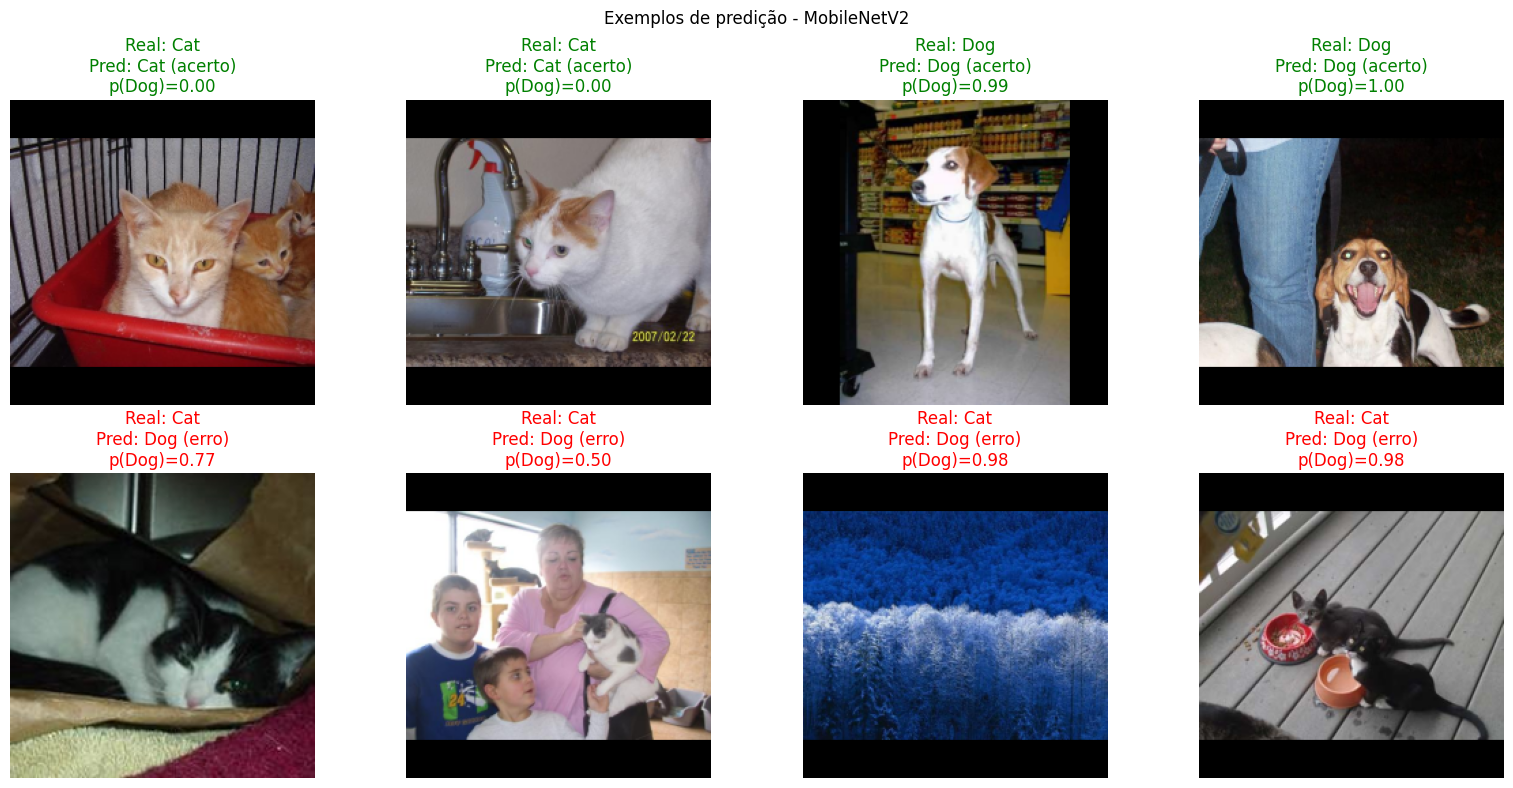

,model,accuracy,macro_f1,weighted_f1,precision_dog,recall_dog,train_total_size,train_model_size,validation_size,test_size,epochs_configured,fine_tune_epochs,examples_saved
1,ResNet50,0.988930,0.988930,0.988930,0.985692,0.992265,17493,14869,2624,7498,8,0,8
2,MobileNetV2,0.984663,0.984662,0.984662,0.980942,0.988530,17493,14869,2624,7498,8,0,8
0,VGG16,0.976527,0.976527,0.976527,0.973496,0.979728,17493,14869,2624,7498,8,0,8


In [29]:
all_metrics = []

for model_name in MODEL_ORDER:
    metrics = train_and_evaluate_model(model_name)
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics).sort_values("accuracy", ascending=False)
metrics_df.to_csv(OUTPUT_DIR / "metrics_transfer_learning.csv", index=False)
metrics_df

## 9. Comparação final

,model,accuracy,macro_f1,weighted_f1,precision_dog,recall_dog
1,ResNet50,0.988930,0.988930,0.988930,0.985692,0.992265
2,MobileNetV2,0.984663,0.984662,0.984662,0.980942,0.988530
0,VGG16,0.976527,0.976527,0.976527,0.973496,0.979728


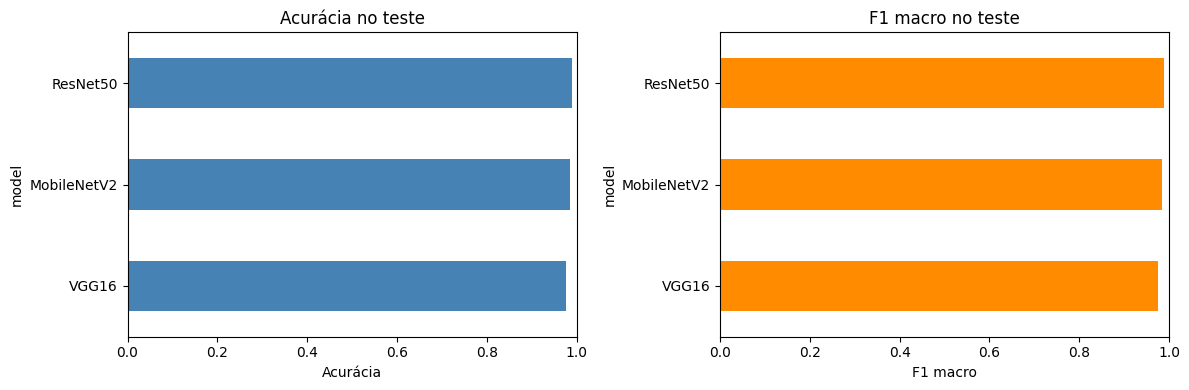

In [30]:
display(metrics_df[["model", "accuracy", "macro_f1", "weighted_f1", "precision_dog", "recall_dog"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_df.sort_values("accuracy").plot.barh(x="model", y="accuracy", ax=axes[0], legend=False, color="steelblue")
axes[0].set_xlim(0, 1)
axes[0].set_title("Acurácia no teste")
axes[0].set_xlabel("Acurácia")

metrics_df.sort_values("macro_f1").plot.barh(x="model", y="macro_f1", ax=axes[1], legend=False, color="darkorange")
axes[1].set_xlim(0, 1)
axes[1].set_title("F1 macro no teste")
axes[1].set_xlabel("F1 macro")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Arquivos gerados

Depois da execução completa, os resultados ficam em `outputs/partB/`:

- `metrics_transfer_learning.csv`: comparação entre VGG16, ResNet50 e MobileNetV2;
- `model_comparison.png`: gráfico comparativo;
- subpasta por modelo com matriz de confusão, relatório, exemplos, curvas e modelo `.keras`;
- `test_predictions_<modelo>.csv`: predições individuais no teste.